# Tokamaker/eqdsk TORAX geometry comparison

This notebook is intended to isolate the differences in geometry between an eqdsk created by TokaMaker and what is retrieved from the `data_tree` results from a TORAX simulation.

TokaMaker is run by calling `iter_hmode_tm.py`, see that file for specifics on the equilibrium. It is an ITER 15 MA H-mode equilibrium.

TORAX is set up using the simplest possible configuration, because this notebook is only interested in the geometry after it is interpreted by TORAX, so the profile evolutions don't matter. It is run just so there is an output `data_tree` object to retrieve the geometry from.

Geometry and other parameters are extracted from the eqdsk file using `read_eqdsk_extended` (based on OMFIT functions and compared to OMFIT in `omfit_v_tm_eqdsk.ipynb`) and from the TokaMaker object `mygs` into the `tm` dict.

Similar parameters are extracted from the TORAX output `data_tree` into the `tx` dict. Profiles are interpolated onto the `psi_N` grid using `pull_torax_onto_psi` function. This function might have errors. Note: I could not find exact R and Z values for the LCFS in the TORAX `data_tree` so I plotted the LCFS using Miller geometry calculated from the shaping parameters available from TORAX: `R, Z, a, kappa, delta`.

In [2]:
import torax
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk
import matplotlib.pyplot as plt
from omfit_classes.omfit_eqdsk import OMFITgeqdsk
import numpy as np
import os
from scipy.interpolate import interp1d
%config InlineBackend.figure_format = "retina"

from read_eqdsk_extended import read_eqdsk_extended

eqdsk_file = os.path.join(os.getcwd(), '2026-02-10_iter_rampup_new/out/iter_new_i=0.eqdsk')

15:04:11 CRITICAL Could not import 'imas_core': No module named 'imas_core'. Some functionality is not available. @imas_interface.py:34
2026-02-18 15:04:11,195 [CRITICAL] Could not import 'imas_core': No module named 'imas_core'. Some functionality is not available.


In [1]:
# run TokaMaker
# %run iter_hmode_tm.py

In [3]:
# # plot TokaMaker result and save eqdsk file
# fig, ax = plt.subplots(1,1,figsize=(9,9))
# mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
# mygs.plot_psi(fig,ax,xpoint_color=None,vacuum_nlevels=4)
# mygs.plot_constraints(fig,ax,isoflux_color='tab:red',isoflux_marker='o')

# mygs.print_info()

# mygs.save_eqdsk(eqdsk_file, cocos=2)

In [4]:
# load tm dict from eqdsk file
tm_eqdsk = read_eqdsk_extended(eqdsk_file)

tm = {
    'R': tm_eqdsk['rcentr'],
    'Z': tm_eqdsk['zaxis'],
    'B0': tm_eqdsk['bcentr'],
    'Ip': tm_eqdsk['ip'],
    'psi_axis': tm_eqdsk['psimag'],
    'psi_lcfs': tm_eqdsk['psibry'],

    'q_prof': tm_eqdsk['qpsi'],
    'q_axis': tm_eqdsk['qpsi'][0],
    'q_lcfs': tm_eqdsk['qpsi'][-1],

    'vol': tm_eqdsk['vol'],
    'vol_lcfs': tm_eqdsk['vol_lcfs'],
    'vpr': tm_eqdsk['vpr'],
    'R_inv_avg': tm_eqdsk['R_inv_avg'],
    'R_avg': tm_eqdsk['R_avg'],

    'psi_N': tm_eqdsk['psi_n'],
    'psi': tm_eqdsk['psi'],
}


In [6]:
# run TORAX with minimum input configuration
config_dict = {
    'plasma_composition': {
        'main_ion': {'D': 0.5, 'T': 0.5},
    },
    'geometry': {
        'geometry_type': 'eqdsk',
        'geometry_directory': os.getcwd(),
        'geometry_file': eqdsk_file,
        'Ip_from_parameters': False,
        'cocos': 2,
        'last_surface_factor': 0.98
    },
    'numerics': {
        't_initial': 0.0,
        't_final': 0.001,
        'fixed_dt': 0.001,
        'evolve_ion_heat': False,
        'evolve_electron_heat': False,
        'evolve_current': False,
        'evolve_density': False,
    },
    'profile_conditions': {
        'normalize_n_e_to_nbar': False,
        'n_e_nbar_is_fGW': False,
        'initial_psi_from_j': False,
    },
    'sources': {},
    'pedestal': {
        'set_pedestal': False,
    },
    'transport': {
        'model_name': 'qlknn'
    },
    'solver': {
        'solver_type': 'newton_raphson',
        'use_pereverzev': True,
    },
    'numerics': {
        't_initial': 0.0,
        't_final': 0.001,
        'fixed_dt': {0.0: 0.001},  # Time-varying dict format
        'evolve_ion_heat': False,
        'evolve_electron_heat': False,
        'evolve_current': False,
        'evolve_density': False,
    },
}

config = torax.ToraxConfig.from_dict(config_dict)
data_tree, _ = torax.run_simulation(config)

2026-02-18 15:04:45,823 [ WARNING] User-specified COCOS 2 for EQDSK file has a (R, Z, phi) coordinate system (sigma_RphiZ = -1), but the EQDSK format specifies a (R, phi, Z) coordinate system (sigma_RphiZ = +1). This may result in unexpected behaviour.


ValidationError: 1 validation error for ToraxConfig
  Value error, Volumes are not monotonically increasing (got decrease in volume between surfaces 93 -> 94, 94 -> 95, 95 -> 96, 96 -> 97, 97 -> 98, 98 -> 99). This likely means that the contour generation failed to produce a closed flux surface at these indices. To fix, try reducing last_surface_factor or n_surfaces. [type=value_error, input_value={'plasma_composition': {'...'use_pereverzev': True}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error

In [ ]:
# pull_torax_onto_psi function interpolates TORAX profiles from rho_toroidal to psi_norm grid
def pull_torax_onto_psi(data_tree, var_name, psi_N, time, load_into_state='results', normalize=False, profile_type='linterp'):
    r'''! Load TORAX variable onto psi_norm grid.
    @param data_tree TORAX output data tree.
    @param var_name Name of variable (e.g., 'T_i', 'j_ohmic', 'FFprime').
    @param time Time value to extract.
    @param load_into_state If 'state' loads into '_state', elif 'results' loads into '_results', elif None, return (psi, data).
    @param normalize If True, normalize profile: subtract edge value, divide by core value (for FFprime, pprime).
    @param profile_type Type key for returned dict: 'linterp' or 'jphi-linterp'. Default is 'linterp'.
    '''

    # Extract variable from profiles
    var = getattr(data_tree.profiles, var_name)
    var_data = var.sel(time=time, method='nearest').to_numpy()

    # Automatically detect which rho coordinate this variable uses
    if 'rho_cell_norm' in var.coords:
        grid = 'rho_cell_norm'
    elif 'rho_face_norm' in var.coords:
        grid = 'rho_face_norm'
    elif 'rho_norm' in var.coords:
        grid = 'rho_norm'
    else:
        raise ValueError(f"Variable {var_name} does not have a recognized rho coordinate")

    # Get rho_tor coordinate for this variable
    rho_tor = var.coords[grid].values

    # Get psi_norm on rho_face_norm grid and psi on rho_norm grid
    psi_norm_face = data_tree.profiles.psi_norm.sel(time=time, method='nearest').to_numpy()
    psi_rho_norm = data_tree.profiles.psi.sel(time=time, method='nearest').to_numpy()
    psi_norm_rho_norm = (psi_rho_norm - psi_rho_norm[0]) / (psi_rho_norm[-1] - psi_rho_norm[0])

    # Correct second element to avoid degeneracy from zero-gradient BC at core
    psi_norm_rho_norm[1] = (psi_norm_face[0] + psi_norm_face[1]) / 2.0

    # Convert psi to same grid as variable
    if grid == 'rho_cell_norm':
        psi_on_grid = psi_norm_rho_norm[1:-1]
    elif grid == 'rho_face_norm':
        psi_on_grid = psi_norm_face
    elif grid == 'rho_norm':
        psi_on_grid = psi_norm_rho_norm

    # Interpolate onto uniform psi grid
    data_on_psi = interp1d(psi_on_grid, var_data, kind='linear',
                        fill_value='extrapolate', bounds_error=False)(psi_N)


    # Normalize if requested
    if normalize:
        if grid == 'rho_cell_norm':
            # Cell-centered variables don't have a value at psi=0
            # Find the index in data_on_psi closest to the first cell center
            core_idx = np.argmin(np.abs(psi_N - psi_on_grid[0]))
            data_on_psi /= data_on_psi[core_idx]
        else:
            # Face or extended grid has actual core value at psi=0
            data_on_psi /= data_on_psi[0]

    if load_into_state == 'state':
        return {'x': psi_N.copy(), 'y': data_on_psi.copy(), 'type': profile_type}
    elif load_into_state == 'results':
        return data_on_psi.copy()
    else:
        return data_on_psi

In [ ]:
# load tx dict
t=0
tx={
    'R': data_tree.scalars.R_major.sel(time=t, method='nearest'),
    'Z': data_tree.scalars.z_magnetic_axis.sel(time=t, method='nearest'),
    'B0': data_tree.scalars.B_0.sel(time=t, method='nearest'),
    'Ip': data_tree.scalars.Ip.sel(time=t, method='nearest'),
    'psi_axis': data_tree.profiles.psi.sel(time=t, method='nearest').to_numpy()[0]/(2*np.pi),
    'psi_lcfs': data_tree.profiles.psi.sel(time=t, method='nearest').to_numpy()[-1]/(2*np.pi),

    'q_prof': pull_torax_onto_psi(data_tree, 'q', psi_N, time=t),
    'q_axis': pull_torax_onto_psi(data_tree, 'q', psi_N, time=t)[0],
    'q_lcfs': pull_torax_onto_psi(data_tree, 'q', psi_N, time=t)[-1],

    'vol': pull_torax_onto_psi(data_tree, 'volume', psi_N, time=t),
    'vol_lcfs': data_tree.profiles.volume.sel(time=t, method='nearest').to_numpy()[-1],
    'vpr':    pull_torax_onto_psi(data_tree, 'vpr', psi_N, time=t),
    'R_inv_avg': pull_torax_onto_psi(data_tree, 'gm9', psi_N, time=t),

    'psi_N': pull_torax_onto_psi(data_tree, 'psi_norm', psi_N, time=t),
    'psi': pull_torax_onto_psi(data_tree, 'psi', psi_N, time=t) / (2.0 * np.pi),
    'psi_from_geo': pull_torax_onto_psi(data_tree, 'psi_from_geo', psi_N, time=t) / (2.0 * np.pi),
    'psi_from_Ip': pull_torax_onto_psi(data_tree, 'psi_from_Ip', psi_N, time=t) / (2.0 * np.pi),
}

In [ ]:
# comparison table for scalar values

tm_keys = set(tm.keys())
tx_keys = set(tx.keys())
common_keys = tm_keys & tx_keys

scalar_keys = []
profile_keys = []

for key in common_keys:
    if isinstance(tm[key], (int, float, np.integer, np.floating)):
        scalar_keys.append(key)
    elif hasattr(tm[key], '__len__'):
        profile_keys.append(key)

print(f"\n{'Parameter':<20} {'eqdsk':<20} {'TORAX':<20} {'Diff %':<15}")
print("-"*75)

for key in sorted(scalar_keys):
    tm_val = float(tm[key])
    tx_val = float(tx[key])
    diff_pct = 100 * (tx_val - tm_val) / tm_val if tm_val != 0 else 0
    print(f"{key:<20} {tm_val:<20.6g} {tx_val:<20.6g} {diff_pct:>14.4f}%")


Parameter            eqdsk                TORAX                Diff %         
---------------------------------------------------------------------------
B0                   5.36281              5.36281                      0.0000%
Ip                   1.3e+07              1.30112e+07                  0.0858%
R                    6.22621              6.22621                      0.0000%
Z                    0.526418             0.526418                     0.0000%
psi_axis             -19.2763             -19.2559                    -0.1057%
psi_lcfs             -10.0177             -10.6016                     5.8284%
q_axis               1.37993              1.46846                      6.4149%
q_lcfs               4.20657              3.16436                    -24.7758%
vol_lcfs             797.491              737.18                      -7.5625%


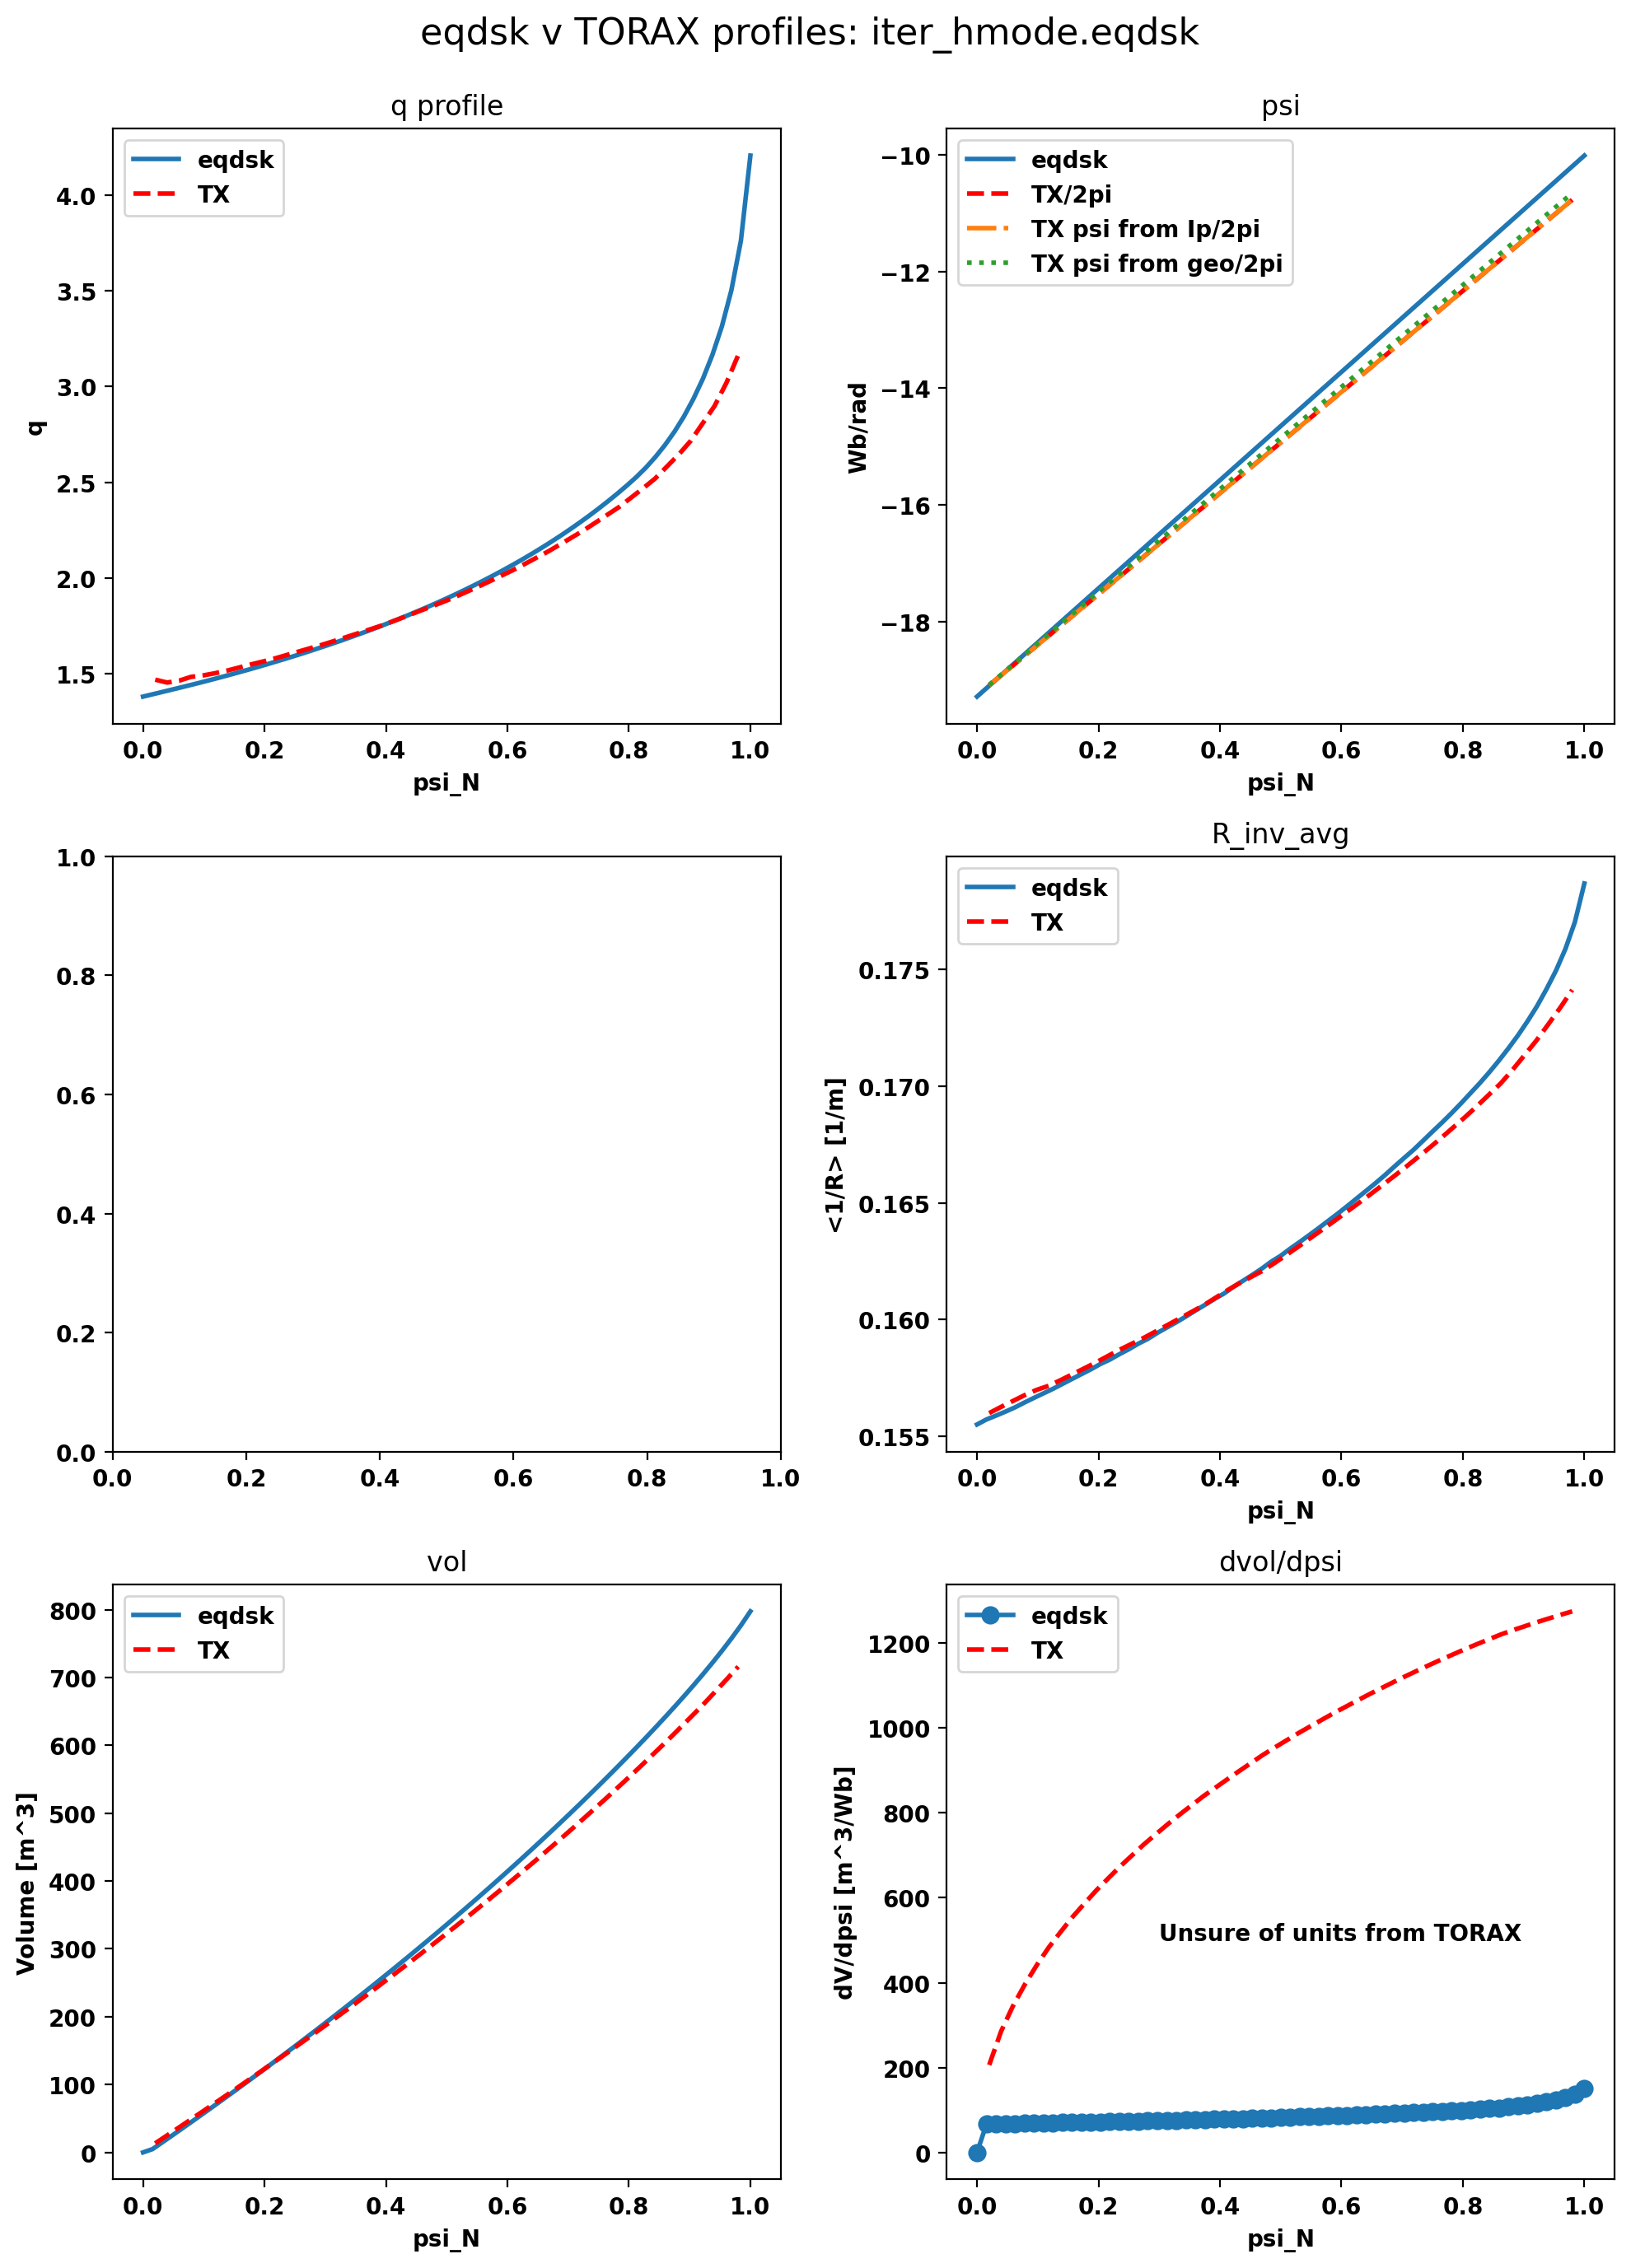

In [ ]:
# Profile comparison plots
fig, axes = plt.subplots(3,2,figsize=(10,14))
fig.suptitle(f'eqdsk v TORAX profiles: {eqdsk_file} \n ', fontsize=16)

ax00 = axes[0,0]
ax01 = axes[0,1]
ax10 = axes[1,0]
ax11 = axes[1,1]
ax20 = axes[2,0]
ax21 = axes[2,1]

ax00.set_title('q profile')
ax00.plot(tm['psi_N'], tm['q_prof'], label='eqdsk')
ax00.plot(tx['psi_N'], tx['q_prof'], 'r--', label='TX')
ax00.set_ylabel('q')
ax00.set_xlabel('psi_N')
ax00.legend()

ax01.set_title('psi')
ax01.plot(tm['psi_N'], tm['psi'], label='eqdsk')
ax01.plot(tx['psi_N'], tx['psi'], 'r--', label='TX/2pi')
ax01.plot(tx['psi_N'], tx['psi_from_Ip'], '-.', label = 'TX psi from Ip/2pi')
ax01.plot(tx['psi_N'], tx['psi_from_geo'], ':', label = 'TX psi from geo/2pi')
ax01.set_ylabel('Wb/rad')
ax01.set_xlabel('psi_N')
ax01.legend()

# ax10.set_title('R_avg')
# ax10.plot(tm['psi_N'], tm['R_avg'], label='eqdsk')
# ax10.plot(tx['psi_N'], tx['R_inv_avg'], 'r--', label='TX (not available)', alpha=0.3)
# ax10.legend()

ax11.set_title('R_inv_avg')
ax11.plot(tm['psi_N'], tm['R_inv_avg'], label='eqdsk')
ax11.plot(tx['psi_N'], tx['R_inv_avg'], 'r--', label='TX')
ax11.set_ylabel('<1/R> [1/m]')
ax11.set_xlabel('psi_N')
ax11.legend()

ax20.set_title('vol')
ax20.plot(tm['psi_N'], tm['vol'], label='eqdsk')
ax20.plot(tx['psi_N'], tx['vol'], 'r--', label='TX')
ax20.set_ylabel('Volume [m^3]')
ax20.set_xlabel('psi_N')
ax20.legend()

ax21.set_title('dvol/dpsi')
ax21.plot(tm['psi_N'], tm['vpr'], label='eqdsk', marker='o')
ax21.plot(tx['psi_N'], tx['vpr'], 'r--', label='TX')
ax21.text(0.3,500, 'Unsure of units from TORAX')
ax21.set_ylabel('dV/dpsi [m^3/Wb]')
ax21.set_xlabel('psi_N')
ax21.legend()

fig.tight_layout()


In [ ]:
# extract geometry parameters from TORAX and construct LCFS using Miller geometry
dt = data_tree
ds = dt["profiles"].ds

t_idx = 0
time_val = 0

# --- Select LCFS (rho_norm = 1, i.e. last radial index) ---
lcfs = ds.isel(time=t_idx).isel(rho_norm=-1)

R_out = float(lcfs["R_out"])          # outer midplane R
R_in  = float(lcfs["R_in"])           # inner midplane R
kappa = float(lcfs["elongation"])     # elongation

# delta on face norm — select last face point for LCFS
delta_u = float(ds["delta_upper"].isel(time=t_idx).isel(rho_face_norm=-1))
delta_l = float(ds["delta_lower"].isel(time=t_idx).isel(rho_face_norm=-1))

# Derived geometric quantities
a = (R_out - R_in) / 2.0             # minor radius at LCFS
R0 = (R_out + R_in) / 2.0            # major radius at LCFS

Z0 = float(dt["scalars"].ds["z_magnetic_axis"].isel(time=t_idx))

print(f"TORAX:")
print(f"R0 = {R0:.3f} m, Z0 = {Z0:.3f} m, a = {a:.3f} m, kappa = {kappa:.3f}")
print(f"delta_upper = {delta_u:.3f}, delta_lower = {delta_l:.3f}")

# Miller parameterization
# Upper half: theta in [0, pi],   uses delta_upper
# Lower half: theta in [pi, 2pi], uses delta_lower
theta_up = np.linspace(0, np.pi, 200)
theta_lo = np.linspace(np.pi, 2 * np.pi, 200)

def miller_R(theta, R0, a, delta):
    return R0 + a * np.cos(theta + np.arcsin(delta) * np.sin(theta))

def miller_Z(theta, a, kappa):
    return Z0 + kappa * a * np.sin(theta)


R_lcfs = np.concatenate([
    miller_R(theta_up, R0, a, delta_u),
    miller_R(theta_lo, R0, a, delta_l),
])
Z_lcfs = np.concatenate([
    miller_Z(theta_up, a, kappa),
    miller_Z(theta_lo, a, kappa),
])

# ax.plot(R_lcfs, Z_lcfs, "b-", linewidth=2)

TORAX:
R0 = 6.240 m, Z0 = 0.526 m, a = 1.903 m, kappa = 1.740
delta_upper = 0.325, delta_lower = 0.364


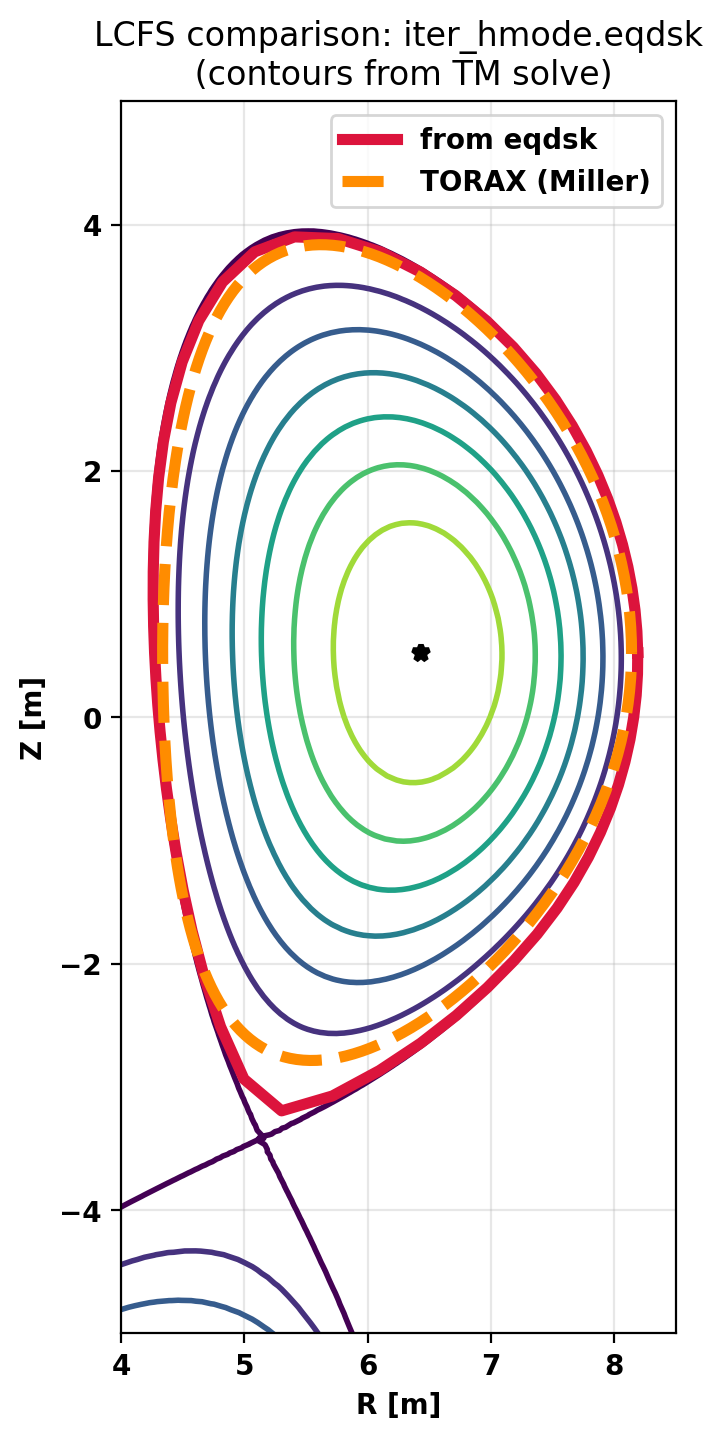

In [ ]:
# Compare LCFS boundaries from TokaMaker and TORAX
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_aspect('equal')
ax.set_title(f'LCFS comparison: {eqdsk_file}\n (contours from TM solve)')
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_ylim(-5,5)
ax.set_xlim(4,8.5)

mygs.plot_psi(fig,ax,xpoint_color=None,vacuum_nlevels=0)


# plot eqdsk geometry
tm_R = tm_eqdsk['rzout'][:, 0]
tm_Z = tm_eqdsk['rzout'][:, 1]
ax.plot(tm_R, tm_Z, '-', color='crimson', linewidth=4, label='from eqdsk')
ax.plot(R_lcfs, Z_lcfs, "--", color='darkorange', linewidth=4, label = 'TORAX (Miller)')

ax.legend()
ax.grid(True, alpha=0.3)

# Debug: COCOS Conversion Issue

The geometry mismatch may be due to incorrect COCOS conversion from COCOS 2 (Wb/rad) to COCOS 11 (Wb).

**Key relationship:** ψ_COCOS11 = 2π × ψ_COCOS2

If psi is not properly converted:
- Φ = ∫ q dψ will be off by factor of 2π  
- vpr = 4π Φ_b ρ_norm / (F <1/R²>) will be off by 2π
- Volume = ∫ vpr dρ_norm will be off by 2π
- All flux-surface-averaged quantities that depend on integration over psi will be wrong

Run the cells below to diagnose where the conversion fails.

In [ ]:
# Debug: Check the COCOS conversion - does eqdsk package properly convert psi?
from eqdsk import EQDSKInterface

# Load with COCOS 2 (original file)
eqdsk_cocos2 = EQDSKInterface.from_file(eqdsk_file, from_cocos=2, to_cocos=2)
# Load with COCOS 11 (what TORAX uses internally)
eqdsk_cocos11 = EQDSKInterface.from_file(eqdsk_file, from_cocos=2, to_cocos=11)

print("COCOS 2 (Wb/rad) - from original file:")
print(f"  psimag = {eqdsk_cocos2.psimag:.6e}")
print(f"  psibdry = {eqdsk_cocos2.psibdry:.6e}")
print(f"  psi range = {eqdsk_cocos2.psibdry - eqdsk_cocos2.psimag:.6e}")
print(f"  bcentre = {eqdsk_cocos2.bcentre:.6e}")

print("\nCOCOS 11 (Wb) - after conversion:")
print(f"  psimag = {eqdsk_cocos11.psimag:.6e}")
print(f"  psibdry = {eqdsk_cocos11.psibdry:.6e}")
print(f"  psi range = {eqdsk_cocos11.psibdry - eqdsk_cocos11.psimag:.6e}")
print(f"  bcentre = {eqdsk_cocos11.bcentre:.6e}")

print("\nRatio (should be 2π if psi converted from Wb/rad to Wb):")
print(f"  psi range ratio = {(eqdsk_cocos11.psibdry - eqdsk_cocos11.psimag) / (eqdsk_cocos2.psibdry - eqdsk_cocos2.psimag):.6f}")
print(f"  Expected: {2*np.pi:.6f}")

COCOS 2 (Wb/rad) - from original file:
  psimag = -1.927632e+01
  psibdry = -1.001772e+01
  psi range = 9.258600e+00
  bcentre = 5.362809e+00

COCOS 11 (Wb) - after conversion:
  psimag = 1.211167e+02
  psibdry = 6.294321e+01
  psi range = -5.817350e+01
  bcentre = -5.362809e+00

Ratio (should be 2π if psi converted from Wb/rad to Wb):
  psi range ratio = -6.283185
  Expected: 6.283185


In [ ]:
# Check if the vpr formula depends on psi being in correct units
# The formula used is: vpr = 4 * np.pi * Phi[-1] * rhon / (F * flux_surf_avg_1_over_R2)
# And Phi is calculated as: Phi = ∫ q * dψ
# If ψ is off by factor of 2π, then Phi and vpr will also be off!

print("\nDiagnostic: Check if volume calculations are affected by psi units")
print(f"If psi is in wrong units (Wb/rad instead of Wb), then:")
print(f"  - Phi will be too small by factor of 2π")
print(f"  - vpr will be too small by factor of 2π  ")
print(f"  - Volume will be too small by factor of 2π")
print(f"\nObserved volume ratio (TORAX/eqdsk): {tx['vol_lcfs']/tm['vol_lcfs']:.6f}")
print(f"Expected if psi unit error: {1/(2*np.pi):.6f}")


Diagnostic: Check if volume calculations are affected by psi units
If psi is in wrong units (Wb/rad instead of Wb), then:
  - Phi will be too small by factor of 2π
  - vpr will be too small by factor of 2π  
  - Volume will be too small by factor of 2π

Observed volume ratio (TORAX/eqdsk): 0.924375
Expected if psi unit error: 0.159155


In [ ]:
# Check if 2D psi grid is also converted
print("\nCheck 2D psi grid conversion:")
print(f"COCOS 2: psi 2D grid max = {eqdsk_cocos2.psi.max():.6e}")
print(f"COCOS 11: psi 2D grid max = {eqdsk_cocos11.psi.max():.6e}")
print(f"Ratio: {eqdsk_cocos11.psi.max() / eqdsk_cocos2.psi.max():.6f}")
print(f"Expected: {2*np.pi:.6f}")

# Also check qpsi (safety factor array)
print("\nCheck if q profile changes (it shouldn't, it's dimensionless):")
print(f"COCOS 2: qpsi[-1] = {eqdsk_cocos2.qpsi[-1]:.6f}")
print(f"COCOS 11: qpsi[-1] = {eqdsk_cocos11.qpsi[-1]:.6f}")
print(f"Ratio: {eqdsk_cocos11.qpsi[-1] / eqdsk_cocos2.qpsi[-1]:.6f} (should be 1.0)")


Check 2D psi grid conversion:
COCOS 2: psi 2D grid max = 9.445927e+00
COCOS 11: psi 2D grid max = 1.211071e+02
Ratio: 12.821098
Expected: 6.283185

Check if q profile changes (it shouldn't, it's dimensionless):
COCOS 2: qpsi[-1] = 4.206572
COCOS 11: qpsi[-1] = 4.206572
Ratio: 1.000000 (should be 1.0)


In [ ]:
# Direct comparison: Does TORAX psi/2pi equal the EQDSK file psi?
print("\n=== KEY TEST: Compare psi values ===")
print(f"From EQDSK file (should be in Wb/rad):")
print(f"  tm psi_axis = {tm['psi_axis']:.6e} Wb/rad")
print(f"  tm psi_lcfs = {tm['psi_lcfs']:.6e} Wb/rad")
print(f"  tm psi range = {tm['psi_lcfs'] - tm['psi_axis']:.6e} Wb/rad")

print(f"\nFrom TORAX output (internal units = Wb, divided by 2π for comparison):")
print(f"  tx psi_axis = {tx['psi_axis']:.6e} Wb/rad")
print(f"  tx psi_lcfs = {tx['psi_lcfs']:.6e} Wb/rad")
print(f"  tx psi range = {tx['psi_lcfs'] - tx['psi_axis']:.6e} Wb/rad")

print(f"\nRatio (TORAX/EQDSK):")
print(f"  psi range = {(tx['psi_lcfs'] - tx['psi_axis'])/(tm['psi_lcfs'] - tm['psi_axis']):.6f}")

print(f"\nIf this ratio is ~{1/(2*np.pi):.4f}, then TORAX failed to convert psi from COCOS 2 to COCOS 11!")
print(f"If this ratio is ~1.0, then the conversion worked.")


=== KEY TEST: Compare psi values ===
From EQDSK file (should be in Wb/rad):
  tm psi_axis = -1.927632e+01 Wb/rad
  tm psi_lcfs = -1.001772e+01 Wb/rad
  tm psi range = 9.258600e+00 Wb/rad

From TORAX output (internal units = Wb, divided by 2π for comparison):
  tx psi_axis = -1.925594e+01 Wb/rad
  tx psi_lcfs = -1.060159e+01 Wb/rad
  tx psi range = 8.654349e+00 Wb/rad

Ratio (TORAX/EQDSK):
  psi range = 0.934736

If this ratio is ~0.1592, then TORAX failed to convert psi from COCOS 2 to COCOS 11!
If this ratio is ~1.0, then the conversion worked.


In [ ]:
# Additional diagnostic: Check if 2D psi field is consistent with boundary values
print("\n=== Detailed 2D PSI Analysis ===")
print(f"COCOS 2:")
print(f"  2D psi min (axis) = {eqdsk_cocos2.psi.min():.6e}")
print(f"  2D psi max = {eqdsk_cocos2.psi.max():.6e}")
print(f"  psimag (from file) = {eqdsk_cocos2.psimag:.6e}")
print(f"  psibdry (from file) = {eqdsk_cocos2.psibdry:.6e}")
print(f"  2D psi range = {eqdsk_cocos2.psi.max() - eqdsk_cocos2.psi.min():.6e}")
print(f"  Boundary psi range = {eqdsk_cocos2.psibdry - eqdsk_cocos2.psimag:.6e}")

print(f"\nCOCOS 11:")
print(f"  2D psi min (axis) = {eqdsk_cocos11.psi.min():.6e}")
print(f"  2D psi max = {eqdsk_cocos11.psi.max():.6e}")
print(f"  psimag (from file) = {eqdsk_cocos11.psimag:.6e}")
print(f"  psibdry (from file) = {eqdsk_cocos11.psibdry:.6e}")
print(f"  2D psi range = {eqdsk_cocos11.psi.max() - eqdsk_cocos11.psi.min():.6e}")
print(f"  Boundary psi range = {eqdsk_cocos11.psibdry - eqdsk_cocos11.psimag:.6e}")

print(f"\nRatio of 2D psi ranges: {(eqdsk_cocos11.psi.max() - eqdsk_cocos11.psi.min())/(eqdsk_cocos2.psi.max() - eqdsk_cocos2.psi.min()):.6f}")
print(f"Ratio of boundary psi ranges: {abs(eqdsk_cocos11.psibdry - eqdsk_cocos11.psimag)/abs(eqdsk_cocos2.psibdry - eqdsk_cocos2.psimag):.6f}")
print(f"Expected: {2*np.pi:.6f}")


=== Detailed 2D PSI Analysis ===
COCOS 2:
  2D psi min (axis) = -1.927480e+01
  2D psi max = 9.445927e+00
  psimag (from file) = -1.927632e+01
  psibdry (from file) = -1.001772e+01
  2D psi range = 2.872073e+01
  Boundary psi range = 9.258600e+00

COCOS 11:
  2D psi min (axis) = -5.935051e+01
  2D psi max = 1.211071e+02
  psimag (from file) = 1.211167e+02
  psibdry (from file) = 6.294321e+01
  2D psi range = 1.804577e+02
  Boundary psi range = -5.817350e+01

Ratio of 2D psi ranges: 6.283185
Ratio of boundary psi ranges: 6.283185
Expected: 6.283185


In [ ]:
# Check if the 93% issue is due to last_surface_factor=0.95
print("\n=== Analysis of last_surface_factor Effect ===")
print(f"Config setting: last_surface_factor = 0.95")
print(f"\nExpected TORAX LCFS at 95% of psi boundary:")

# Calculate where 95% should be
psi_mag_eqdsk = tm['psi_axis']  # in Wb/rad from eqdsk
psi_lcfs_eqdsk = tm['psi_lcfs']  # in Wb/rad from eqdsk
psi_range_eqdsk = psi_lcfs_eqdsk - psi_mag_eqdsk

psi_95_percent = psi_mag_eqdsk + 0.95 * psi_range_eqdsk
print(f"  psi at 95% = {psi_95_percent:.6e} Wb/rad")

psi_range_95 = psi_95_percent - psi_mag_eqdsk
print(f"  psi range to 95% = {psi_range_95:.6e} Wb/rad")
print(f"  Ratio: {psi_range_95/psi_range_eqdsk:.6f} (should be 0.95)")

# What TORAX actually has
psi_mag_torax = tx['psi_axis']  # already converted to Wb/rad for comparison
psi_lcfs_torax = tx['psi_lcfs']  # already converted to Wb/rad
psi_range_torax = psi_lcfs_torax - psi_mag_torax

print(f"\nActual TORAX values:")
print(f"  psi range = {psi_range_torax:.6e} Wb/rad")
print(f"  Ratio to full range: {psi_range_torax/psi_range_eqdsk:.6f}")
print(f"  Ratio to 95% range: {psi_range_torax/psi_range_95:.6f}")

print(f"\nVolume expectation:")
print(f"  For ρ_max = sqrt(0.95) = {np.sqrt(0.95):.6f}")
print(f"  Volume ratio ≈ (ρ_max)^3 = {np.sqrt(0.95)**3:.6f}")
print(f"  Observed volume ratio: {tx['vol_lcfs']/tm['vol_lcfs']:.6f}")


=== Analysis of last_surface_factor Effect ===
Config setting: last_surface_factor = 0.95

Expected TORAX LCFS at 95% of psi boundary:
  psi at 95% = -1.048065e+01 Wb/rad
  psi range to 95% = 8.795670e+00 Wb/rad
  Ratio: 0.950000 (should be 0.95)

Actual TORAX values:
  psi range = 8.654349e+00 Wb/rad
  Ratio to full range: 0.934736
  Ratio to 95% range: 0.983933

Volume expectation:
  For ρ_max = sqrt(0.95) = 0.974679
  Volume ratio ≈ (ρ_max)^3 = 0.925945
  Observed volume ratio: 0.924375
